# Step 3: Terrain and Hydrological Factor Generation

This notebook generates terrain and hydrological conditioning factors for one selected watershed.

It is designed for the multi-watershed workflow:
- Step 2 creates `watershed_1.shp`, `watershed_dem_1.tif`, etc.
- Step 3 processes one watershed at a time using `point_id`
- streams are generated here, not in Step 2

The workflow uses free and open-source tools by default. Optional manual factor rasters can also be supplied through the configuration file.

## Inputs

This notebook expects:
- `watershed_analysis.json`
- watershed outputs from Step 2
- the PyGILE-Plus Docker environment

No manual environment setup is required.

In [210]:
import json
import os
import shutil
import subprocess
import warnings
from pathlib import Path
import grass.script as gs
import grass.script.setup as gsetup
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

GISBASE = subprocess.check_output(["grass", "--config", "path"], text=True).strip()
os.environ["GISBASE"] = GISBASE
os.environ["PATH"] = f"{GISBASE}/bin:{GISBASE}/scripts:" + os.environ.get("PATH", "")

# Do NOT set PROJ_DATA/PROJ_LIB/GDAL_DATA globally — gdalwarp uses conda's PROJ,
# GRASS uses its own. Setting either one globally breaks the other.
# Each tool gets its own env dict at call time instead.
for key in ["PROJ_DATA", "PROJ_LIB", "GDAL_DATA"]:
    os.environ.pop(key, None)

CONDA_PREFIX = os.environ.get("CONDA_PREFIX", "/opt/conda/envs/pygile")
CONDA_PROJ = os.path.join(CONDA_PREFIX, "share", "proj")
CONDA_GDAL = os.path.join(CONDA_PREFIX, "share", "gdal")

print("GISBASE:", GISBASE)
print("Conda PROJ:", CONDA_PROJ)

warnings.filterwarnings("ignore")

with open("watershed_analysis.json", "r") as f:
    config = json.load(f)

os.makedirs(config["temp_dir"], exist_ok=True)
os.makedirs(config["output_dir"], exist_ok=True)

config.setdefault("factor_output_dir", os.path.join(config["output_dir"], "factors"))
config.setdefault("use_foss_factors", True)
config.setdefault("use_manual_factor_inputs", False)
config.setdefault("manual_factor_paths", {})
config.setdefault("factor_crs", None)
config.setdefault("stream_threshold", None)
config.setdefault("grass_factor_project_root", os.path.join(config["temp_dir"], "grass_factor_projects"))
config.setdefault("slope_unit_saga", 0)
config.setdefault("saga_cmd", "saga_cmd")
config.setdefault("saga_lib", "")

os.makedirs(config["factor_output_dir"], exist_ok=True)
os.makedirs(config["grass_factor_project_root"], exist_ok=True)

print("Configuration loaded")
print(f"Output directory: {config['output_dir']}")
print(f"Factor output directory: {config['factor_output_dir']}")

GISBASE: /opt/grass/grass84
Conda PROJ: /opt/conda/envs/pygile/share/proj
Configuration loaded
Output directory: results
Factor output directory: results/factors


In [211]:
# Select which watershed to process
point_id = 1
print(f"Selected watershed point_id: {point_id}")

Selected watershed point_id: 1


In [212]:
def expected_watershed_dem(point_id):
    return os.path.join(config["output_dir"], f"watershed_dem_{point_id}.tif")
 
def expected_watershed_vector(point_id):
    return os.path.join(config["output_dir"], f"watershed_{point_id}.shp")
 
def expected_projected_dem(point_id):
    return os.path.join(config["factor_output_dir"], f"watershed_dem_{point_id}_projected.tif")
 
def expected_stream_raster(point_id):
    return os.path.join(config["factor_output_dir"], f"streams_{point_id}.tif")
 
def expected_stream_vector(point_id):
    return os.path.join(config["factor_output_dir"], f"streams_{point_id}.shp")
 
def expected_factor_path(name, point_id):
    return os.path.join(config["factor_output_dir"], f"{name}_{point_id}.tif")
 
def utm_epsg_from_dataset(raster_path):
    with rasterio.open(raster_path) as src:
        bounds = src.bounds
        crs = src.crs
        if crs and crs.is_projected:
            return crs.to_string()
        center_lon = (bounds.left + bounds.right) / 2
        center_lat = (bounds.bottom + bounds.top) / 2
        zone = int((center_lon + 180) / 6) + 1
        if center_lat >= 0:
            return f"EPSG:{32600 + zone}"
        return f"EPSG:{32700 + zone}"
 
def ensure_projected_dem(input_dem, output_dem):
    target_crs = config["factor_crs"] or utm_epsg_from_dataset(input_dem)
    if os.path.exists(output_dem):
        return output_dem, target_crs
    env = os.environ.copy()
    env["PROJ_DATA"] = CONDA_PROJ
    env["PROJ_LIB"] = CONDA_PROJ
    env["GDAL_DATA"] = CONDA_GDAL
    subprocess.run([
         os.path.join(CONDA_PREFIX, "bin", "gdalwarp"),
        "-t_srs", target_crs,
        "-r", "bilinear",
        "-of", "GTiff",
        input_dem,
        output_dem
    ], check=True, env=env)
    return output_dem, target_crs
 
def copy_manual_factor(factor_name, output_path):
    manual_paths = config.get("manual_factor_paths", {})
    if not config.get("use_manual_factor_inputs", False):
        return False
    if factor_name not in manual_paths:
        return False
    src = manual_paths[factor_name]
    if not src or not os.path.exists(src):
        raise FileNotFoundError(f"Manual factor path for {factor_name} not found: {src}")
    shutil.copy2(src, output_path)
    return True
 
def compute_stats(raster_path):
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)
        values = data.compressed()
        if values.size == 0:
            return {"min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan}
        return {
            "min": float(values.min()),
            "max": float(values.max()),
            "mean": float(values.mean()),
            "std": float(values.std())
        }
 
def run_saga_tool(library, tool_id, parameters, verbose=False):
    env = os.environ.copy()
    env["SAGA_MLB"] = config["saga_lib"]
    env["PROJ_DATA"] = CONDA_PROJ
    env["PROJ_LIB"] = CONDA_PROJ
    env["GDAL_DATA"] = CONDA_GDAL
    cmd = [config["saga_cmd"], library, str(tool_id)] + parameters
    if verbose or config.get("verbose_mode", False):
        print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, env=env, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(f"SAGA tool failed: {library} {tool_id}")
    return result
 
 
def prepare_grass_project(projected_dem, point_id):
    project_dir = os.path.join(config["grass_factor_project_root"], f"grass_factor_project_{point_id}")
    if os.path.exists(project_dir):
        shutil.rmtree(project_dir)
    os.makedirs(config["grass_factor_project_root"], exist_ok=True)

    grass_bin = subprocess.check_output(["which", "grass"], text=True).strip()

    env = os.environ.copy()

    # Strip OTB and conda lib paths — they inject libproj.so.25 and libgeos
    # which conflict with the libproj.so.15 GRASS was compiled against.
    # Keep only GRASS's own lib dir + system paths.
    grass_lib = os.path.join(GISBASE, "lib")
    existing_ld = env.get("LD_LIBRARY_PATH", "")
    filtered_ld = ":".join(
        p for p in existing_ld.split(":")
        if p and "/opt/otb" not in p and "/opt/conda" not in p
    )
    env["LD_LIBRARY_PATH"] = f"{grass_lib}:{filtered_ld}" if filtered_ld else grass_lib

    env.pop("PROJ_DATA", None)
    env.pop("PROJ_LIB", None)
    env.pop("GDAL_DATA", None)

    result = subprocess.run(
        [grass_bin, "-c", projected_dem, "-e", project_dir],
        capture_output=True, text=True, env=env
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(f"Failed to create GRASS project at {project_dir}")

    print(f"GRASS project created: {project_dir}")
    return project_dir, os.path.join(project_dir, "PERMANENT")
 
def grass_exec(session, module, *args):
    kwargs = {}
    flags = ""
    for arg in args:
        # FIX: Handle --overwrite explicitly instead of silently dropping it.
        # Previously, "--overwrite" hit `continue` and was never passed to gs.run_command,
        # meaning overwrite protection was never disabled.
        if arg == "--overwrite":
            kwargs["overwrite"] = True
            continue
        if arg.startswith("--"):
            continue
        if arg.startswith("-") and "=" not in arg:
            flags += arg.lstrip("-")
            continue
        if "=" in arg:
            k, v = arg.split("=", 1)
            kwargs[k] = v
    return gs.run_command(module, flags=flags, env=session.env, **kwargs)
 
def grass_export(session, raster_name, output_path, dtype="Float64"):
    gs.run_command(
        "r.out.gdal",
        input=raster_name,
        output=output_path,
        format="GTiff",
        type=dtype,
        flags="c",      # skip color table export — avoids harmless GDAL warning
        overwrite=True,
        env=session.env,
    )
    
def run_otb_bandmath(inputs, output_path, expression):
    # OTB must run with its own lib dir first in LD_LIBRARY_PATH.
    # The conda and system stacks have incompatible libgdal/libgeotiff versions
    # that cause "undefined symbol: GTIFKeyGetSHORT" at runtime.
    env = os.environ.copy()
    existing_ld = env.get("LD_LIBRARY_PATH", "")
    filtered_ld = ":".join(
        p for p in existing_ld.split(":")
        if p and "/opt/conda" not in p
    )
    env["LD_LIBRARY_PATH"] = f"/opt/otb/lib:{filtered_ld}" if filtered_ld else "/opt/otb/lib"
    env.pop("PROJ_DATA", None)
    env.pop("PROJ_LIB", None)
    env.pop("GDAL_DATA", None)

    cmd = [
        "otbcli_BandMath",
        "-il", *inputs,
        "-out", output_path, "float",
        "-exp", expression
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("OTB BandMath failed")
    return result
 
def derive_stream_threshold(dem_path):
    with rasterio.open(dem_path) as src:
        cell_area = abs(src.res[0] * src.res[1])
        valid = src.read(1, masked=True).count()
    user_threshold = config.get("stream_threshold")
    if user_threshold is not None:
        return int(user_threshold)
    by_count = max(50, int(valid * 0.01))
    by_area = max(1, int(1000 / cell_area)) if cell_area > 0 else 50
    return max(by_count, by_area)
 
def stream_cells_count(raster_path):
    with rasterio.open(raster_path) as src:
        arr = src.read(1)
    return int(np.count_nonzero(arr))

In [213]:
watershed_dem = expected_watershed_dem(point_id)
watershed_vector = expected_watershed_vector(point_id)
 
if not os.path.exists(watershed_dem):
    raise FileNotFoundError(f"Watershed DEM not found: {watershed_dem}")
if not os.path.exists(watershed_vector):
    raise FileNotFoundError(f"Watershed vector not found: {watershed_vector}")
 
projected_dem, factor_crs = ensure_projected_dem(watershed_dem, expected_projected_dem(point_id))
config["factor_crs"] = factor_crs
 
stream_raster = expected_stream_raster(point_id)
stream_vector = expected_stream_vector(point_id)
 
print(f"Watershed DEM: {watershed_dem}")
print(f"Watershed vector: {watershed_vector}")
print(f"Projected DEM: {projected_dem}")
print(f"Factor CRS: {factor_crs}")
print(f"Stream raster target: {stream_raster}")
print(f"Stream vector target: {stream_vector}")

Creating output file that is 999P x 1449L.
Using internal nodata values (e.g. -9999) for image results/watershed_dem_1.tif.
Copying nodata values from source results/watershed_dem_1.tif to destination results/factors/watershed_dem_1_projected.tif.
Processing results/watershed_dem_1.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Watershed DEM: results/watershed_dem_1.tif
Watershed vector: results/watershed_1.shp
Projected DEM: results/factors/watershed_dem_1_projected.tif
Factor CRS: EPSG:32645
Stream raster target: results/factors/streams_1.tif
Stream vector target: results/factors/streams_1.shp


## Stream generation

Streams are generated in Step 3 from the selected watershed DEM.

If `stream_threshold` is not provided in the config, an adaptive threshold is used.

In [214]:
stream_threshold = derive_stream_threshold(projected_dem)
print(f"Using stream extraction threshold: {stream_threshold}")

Using stream extraction threshold: 9501


## GRASS session and stream generation

In [215]:
project_dir, grass_mapset = prepare_grass_project(projected_dem, point_id)
flow_accum_file = expected_factor_path("flow_accumulation", point_id)
 
# FIX: Initialize stream_count to 0 before the GRASS session block so it is always
# defined even if an exception occurs before line 330 in the original.
stream_count = 0
 
grass_lib = os.path.join(GISBASE, "lib")
existing_ld = os.environ.get("LD_LIBRARY_PATH", "")
filtered_ld = ":".join(
    p for p in existing_ld.split(":")
    if p and "/opt/otb" not in p and "/opt/conda" not in p
)
os.environ["LD_LIBRARY_PATH"] = f"{grass_lib}:{filtered_ld}" if filtered_ld else grass_lib

with gsetup.init(project_dir) as session:
    grass_exec(
        session,
        "r.in.gdal",
        f"input={projected_dem}",
        "output=dem",
        "--overwrite",
        "-o"
    )
 
    grass_exec(
        session,
        "g.region",
        "raster=dem",
        "-a"
    )
 
    grass_exec(
        session,
        "r.watershed",
        "elevation=dem",
        "accumulation=flowacc",
        "--overwrite"
    )
 
    grass_exec(
        session,
        "r.mapcalc",
        f"expression=streams = if(flowacc >= {stream_threshold}, 1, null())",
        "--overwrite"
    )
 
    grass_export(session, "flowacc", flow_accum_file)
    grass_export(session, "streams", stream_raster, "Float32")

    # Clamp negative flow accumulation values (GRASS r.watershed artifact)
    with rasterio.open(flow_accum_file, "r+") as src:
        data = src.read(1)
        data[data < 0] = 0
        src.write(data, 1)

    stream_count = stream_cells_count(stream_raster)
 
    if stream_count > 0:
        grass_exec(
            session,
            "r.to.vect",
            "input=streams",
            "output=streams_vect",
            "type=line",
            "--overwrite"
        )
        grass_exec(
            session,
            "v.out.ogr",
            "input=streams_vect",
            f"output={stream_vector}",
            "format=ESRI_Shapefile",
            "--overwrite"
        )
        print(f"Stream vector exported: {stream_vector}")
    else:
        stream_vector = None
        print("No stream cells found. Stream vector export skipped.")

GRASS project created: temp_watershed/grass_factor_projects/grass_factor_project_1


Over-riding projection check
Importing raster map <dem>...

SECTION 1a (of 4): Initiating Memory.
SECTION 1b (of 4): Determining Offmap Flow.

SECTION 2: A* Search.

SECTION 3a: Accumulating Surface Flow with MFD.

SECTION 3b: Adjusting drainage directions.

SECTION 4: Closing Maps.
Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File <results/factors/flow_accumulation_1.tif>
created.
Checking GDAL data type and nodata value...

Using GDAL data type <Float32>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File <re

Stream vector exported: results/factors/streams_1.shp


Exporting 2 features...

v.out.ogr complete. 2 features (Line String type) written to <streams_vect>
(ESRI_Shapefile format).


## Register outputs

In [216]:
factor_files = {}
 
def register_factor(name, path):
    factor_files[name] = path
    print(f"{name}: {path}")
 
elevation_file = expected_factor_path("elevation", point_id)
if not copy_manual_factor("elevation", elevation_file):
    shutil.copy2(projected_dem, elevation_file)
register_factor("elevation", elevation_file)
 
register_factor("flow_accumulation", flow_accum_file)
 
if stream_count > 0:
    register_factor("streams_raster", stream_raster)

elevation: results/factors/elevation_1.tif
flow_accumulation: results/factors/flow_accumulation_1.tif
streams_raster: results/factors/streams_1.tif


In [217]:
# SAGA-derived factors
slope_file = expected_factor_path("slope_deg", point_id)
aspect_file = expected_factor_path("aspect_deg", point_id)
plan_curv_file = expected_factor_path("plan_curvature", point_id)
profile_curv_file = expected_factor_path("profile_curvature", point_id)
twi_file = expected_factor_path("topographic_wetness_index", point_id)
 
# FIX: Use `and` instead of `or`. The original `or` logic ran SAGA if either manual factor
# was missing, but SAGA outputs both files together. With `or`, if one already exists as a
# manual copy it gets silently overwritten. With `and`, SAGA only runs when both are absent.
if not copy_manual_factor("slope", slope_file) and not copy_manual_factor("aspect", aspect_file):
    run_saga_tool(
        "ta_morphometry",
        0,
        [
            f"-ELEVATION={projected_dem}",
            f"-SLOPE={slope_file}",
            f"-ASPECT={aspect_file}",
            f"-UNIT_SLOPE={config.get('slope_unit_saga', 0)}",
            "-UNIT_ASPECT=0"
        ]
    )
register_factor("slope", slope_file)
register_factor("aspect", aspect_file)
 
# FIX: Same `or` -> `and` fix for curvature pair
if not copy_manual_factor("plan_curvature", plan_curv_file) and not copy_manual_factor("profile_curvature", profile_curv_file):
    run_saga_tool(
        "ta_morphometry",
        0,
        [
            f"-ELEVATION={projected_dem}",
            f"-C_PLAN={plan_curv_file}",
            f"-C_PROF={profile_curv_file}"
        ]
    )
register_factor("plan_curvature", plan_curv_file)
register_factor("profile_curvature", profile_curv_file)
 
if not copy_manual_factor("twi", twi_file):
    run_saga_tool(
        "ta_hydrology",
        15,
        [
            f"-DEM={projected_dem}",
            f"-TWI={twi_file}"
        ]
    )
register_factor("twi", twi_file)

slope: results/factors/slope_deg_1.tif
aspect: results/factors/aspect_deg_1.tif
plan_curvature: results/factors/plan_curvature_1.tif
profile_curvature: results/factors/profile_curvature_1.tif
twi: results/factors/topographic_wetness_index_1.tif


In [218]:
# Additional GRASS-derived factors
tri_file = expected_factor_path("terrain_ruggedness_index", point_id)
tpi_file = expected_factor_path("topographic_position_index", point_id)
roughness_file = expected_factor_path("surface_roughness", point_id)
distance_streams_file = expected_factor_path("distance_to_streams", point_id)
 
grass_lib = os.path.join(GISBASE, "lib")
existing_ld = os.environ.get("LD_LIBRARY_PATH", "")
filtered_ld = ":".join(
    p for p in existing_ld.split(":")
    if p and "/opt/otb" not in p and "/opt/conda" not in p
)
os.environ["LD_LIBRARY_PATH"] = f"{grass_lib}:{filtered_ld}" if filtered_ld else grass_lib

with gsetup.init(project_dir) as session:
    grass_exec(
        session,
        "r.in.gdal",
        f"input={projected_dem}",
        "output=dem",
        "--overwrite",
        "-o"
    )
 
    if not copy_manual_factor("tri", tri_file):
        grass_exec(
            session,
            "r.neighbors",
            "input=dem",
            "output=tri",
            "method=stddev",
            "size=3",
            "--overwrite"
        )
        grass_export(session, "tri", tri_file)
    register_factor("tri", tri_file)
 
    if not copy_manual_factor("tpi", tpi_file):
        grass_exec(
            session,
            "r.neighbors",
            "input=dem",
            "output=dem_mean",
            "method=average",
            "size=3",
            "--overwrite"
        )
        grass_exec(
            session,
            "r.mapcalc",
            "expression=tpi = dem - dem_mean",
            "--overwrite"
        )
        grass_export(session, "tpi", tpi_file)
    register_factor("tpi", tpi_file)
 
    if not copy_manual_factor("roughness", roughness_file):
        grass_exec(
            session,
            "r.neighbors",
            "input=dem",
            "output=roughness",
            "method=range",
            "size=3",
            "--overwrite"
        )
        grass_export(session, "roughness", roughness_file)
    register_factor("roughness", roughness_file)
 
    if stream_count > 0:
        if not copy_manual_factor("distance_to_streams", distance_streams_file):
            grass_exec(
                session,
                "r.in.gdal",
                f"input={stream_raster}",
                "output=streams",
                "--overwrite",
                "-o"
            )
            grass_exec(
                session,
                "r.grow.distance",
                "input=streams",
                "distance=dist_streams",
                "--overwrite"
            )
            grass_export(session, "dist_streams", distance_streams_file)
        register_factor("distance_to_streams", distance_streams_file)
    else:
        print("Distance to streams skipped because no stream raster was generated.")

Over-riding projection check
Importing raster map <dem>...


Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File <results/factors/terrain_ruggedness_index_1.tif>
created.


tri: results/factors/terrain_ruggedness_index_1.tif



Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File
<results/factors/topographic_position_index_1.tif> created.


tpi: results/factors/topographic_position_index_1.tif



Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File <results/factors/surface_roughness_1.tif>
created.
Over-riding projection check
Importing raster map <streams>...


roughness: results/factors/surface_roughness_1.tif



Reading raster map <streams>...

Writing output raster maps...

Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Exporting raster data to GTiff format...



distance_to_streams: results/factors/distance_to_streams_1.tif


r.out.gdal complete. File <results/factors/distance_to_streams_1.tif>
created.


In [219]:
# OTB-derived factor: stream power index proxy
spi_file = expected_factor_path("stream_power_index", point_id)
 
if not copy_manual_factor("spi", spi_file):
    run_otb_bandmath(
        [flow_accum_file, slope_file],
        spi_file,
        "(im2b1<=0 ? 0 : log((im1b1 + 1) * tan(im2b1 * 0.01745329252) + 1))"
    )
register_factor("spi", spi_file)

spi: results/factors/stream_power_index_1.tif


## Summary table

In [220]:
rows = []
for name, path in factor_files.items():
    stats = compute_stats(path)
    rows.append({
        "factor": name,
        "path": path,
        "min": stats["min"],
        "max": stats["max"],
        "mean": stats["mean"],
        "std": stats["std"]
    })
 
factor_summary = pd.DataFrame(rows).sort_values("factor").reset_index(drop=True)
factor_summary

,factor,path,min,max,mean,std
0,aspect,results/factors/aspect_deg_1.tif,0.000021,6.283185,3.216039,1.668172
1,distance_to_streams,results/factors/distance_to_streams_1.tif,0.000000,30734.464257,12998.841114,6375.271480
2,elevation,results/factors/elevation_1.tif,759.628174,5847.881836,2807.093506,1234.628784
3,flow_accumulation,results/factors/flow_accumulation_1.tif,0.000000,11120.295659,24.393918,226.961249
4,plan_curvature,results/factors/plan_curvature_1.tif,-2.050818,1.692191,-0.000006,0.011996
5,profile_curvature,results/factors/profile_curvature_1.tif,-0.022677,0.027881,-0.000056,0.002058
6,roughness,results/factors/surface_roughness_1.tif,0.000000,254.192871,45.980139,20.688614
7,slope,results/factors/slope_deg_1.tif,0.094556,75.176849,30.088718,10.719860
8,spi,results/factors/stream_power_index_1.tif,0.000000,8.627745,0.833577,1.079766
9,streams_raster,results/factors/streams_1.tif,1.000000,1.000000,1.000000,0.000000


In [221]:
summary_csv = os.path.join(config["factor_output_dir"], f"factor_summary_{point_id}.csv")
registry_json = os.path.join(config["factor_output_dir"], f"factor_registry_{point_id}.json")
 
factor_summary.to_csv(summary_csv, index=False)
 
with open(registry_json, "w") as f:
    json.dump(factor_files, f, indent=2)
 
print(f"Saved factor summary: {summary_csv}")
print(f"Saved factor registry: {registry_json}")

Saved factor summary: results/factors/factor_summary_1.csv
Saved factor registry: results/factors/factor_registry_1.json


## Quick visualization

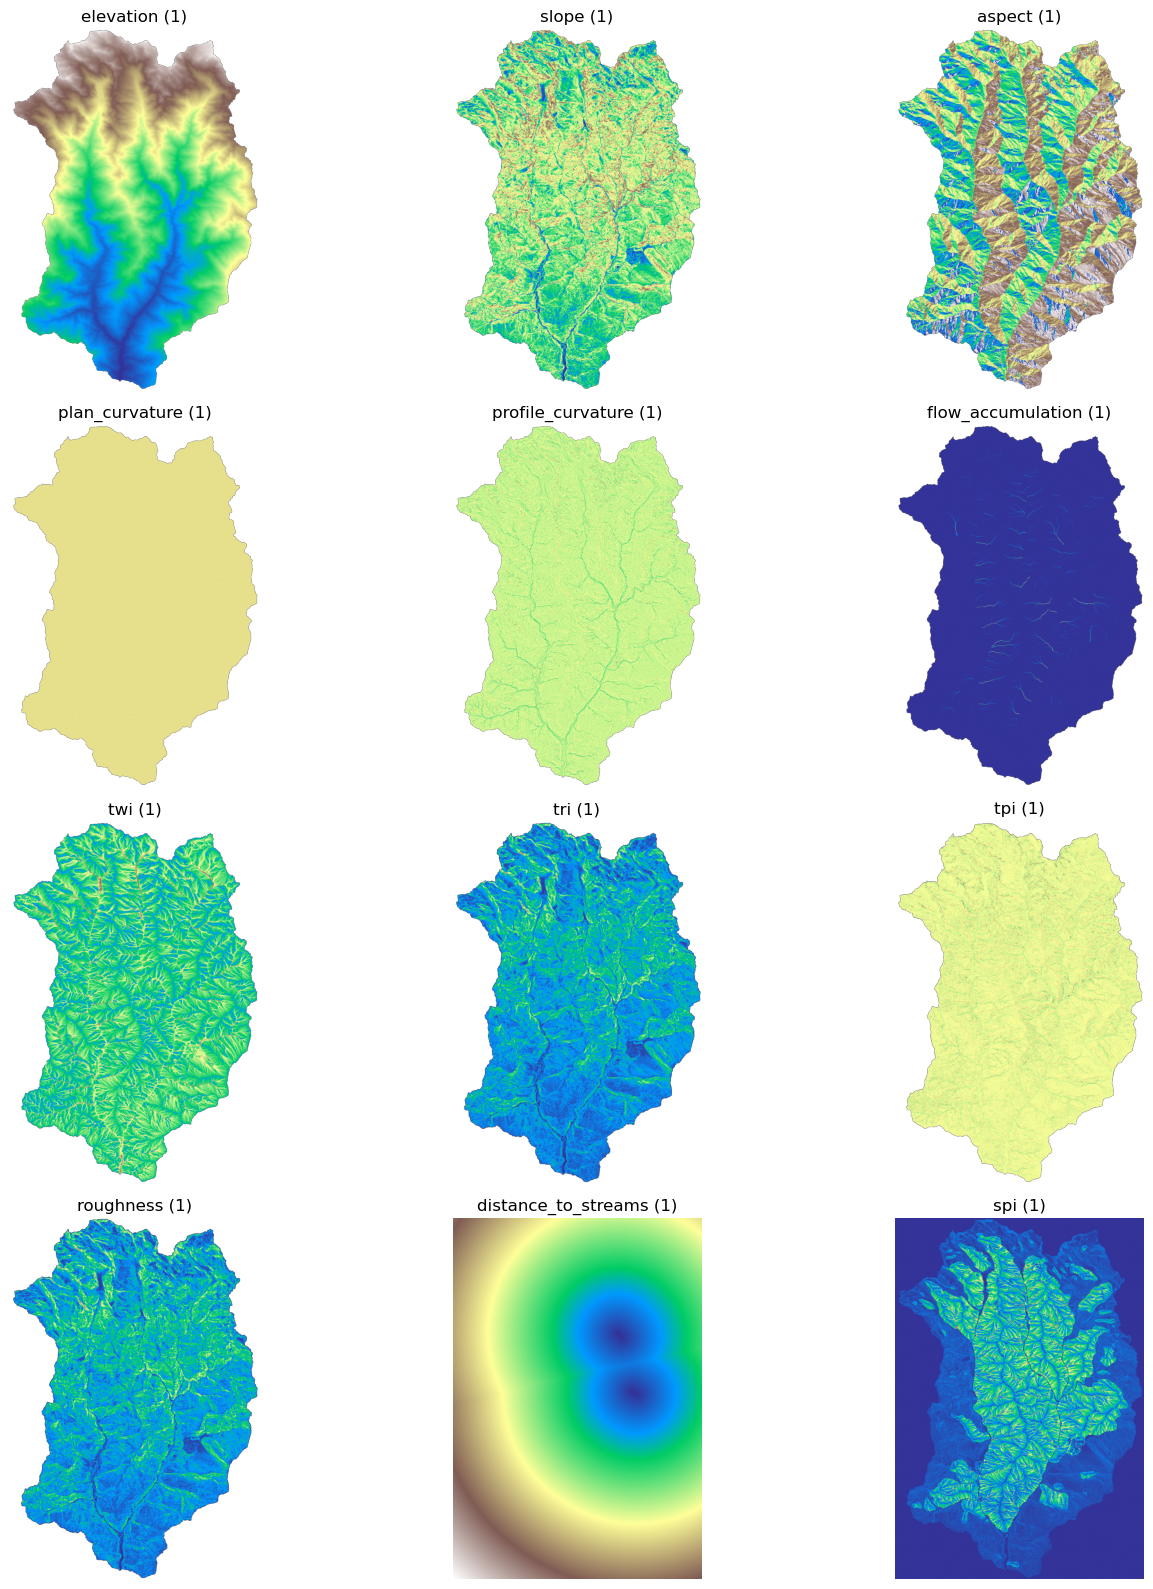

In [222]:
preview_factors = [
    "elevation",
    "slope",
    "aspect",
    "plan_curvature",
    "profile_curvature",
    "flow_accumulation",
    "twi",
    "tri",
    "tpi",
    "roughness",
    "distance_to_streams",
    "spi",
]
 
available_preview = [name for name in preview_factors if name in factor_files]
 
ncols = 3
nrows = int(np.ceil(len(available_preview) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.atleast_1d(axes).ravel()
 
for ax, factor_name in zip(axes, available_preview):
    with rasterio.open(factor_files[factor_name]) as src:
        data = src.read(1, masked=True)
        ax.imshow(data, cmap="terrain")
        ax.set_title(f"{factor_name} ({point_id})")
        ax.set_axis_off()
 
for ax in axes[len(available_preview):]:
    ax.set_axis_off()
 
plt.tight_layout()
plt.show()

## Notes

- This notebook processes one watershed at a time using `point_id`.
- Stream generation is done here from the selected watershed DEM.
- If stream extraction yields no stream cells, stream vector export and distance-to-streams are skipped safely.
- The GRASS workflow uses the official Python session pattern with project creation and `grass.script.setup.init()`.